In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from utils import load_data

X_train, X_test, y_train, y_test = load_data()

In [ ]:
# 1. Label Encoding 
# Trees split on thresholds — they never assume numeric ordering
# matters across categories. "Sales=0, HR=1, Tech=2" is fine
# because the tree asks "is Department == 1?" not "is Department > 1?"
# One-hot encoding would explode feature count and make the tree
# harder to visualize and interpret — the main strength of this model.

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

for col in categorical_cols:
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col]  = le.transform(X_test[col])

# No scaling — completely unnecessary for trees
print("Preprocessing: Label encoded only, no scaling applied")
print("Feature shape:", X_train_enc.shape)

Preprocessing: Label encoded only, no scaling applied
Feature shape: (1176, 30)


C:\Users\shrad\AppData\Local\Temp\ipykernel_10772\3976071814.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
# 2. The overfitting experiment 
# First, grow a fully unconstrained tree — no depth limit.
# This tree will perfectly memorize the training data.
dt_overfit = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_overfit.fit(X_train_enc, y_train)

train_auc_overfit = roc_auc_score(y_train, dt_overfit.predict_proba(X_train_enc)[:, 1])
test_auc_overfit  = roc_auc_score(y_test,  dt_overfit.predict_proba(X_test_enc)[:, 1])

print(f"\n── Fully grown tree (no depth limit) ──")
print(f"Max depth reached : {dt_overfit.get_depth()}")
print(f"Total leaf nodes  : {dt_overfit.get_n_leaves()}")
print(f"Train AUC : {train_auc_overfit:.4f}  ← memorized training data")
print(f"Test AUC  : {test_auc_overfit:.4f}  ← falls apart on unseen data")


── Fully grown tree (no depth limit) ──
Max depth reached : 13
Total leaf nodes  : 156
Train AUC : 1.0000  ← memorized training data
Test AUC  : 0.5720  ← falls apart on unseen data


In [ ]:
# 3. Depth experiment 
# Now systematically vary max_depth and watch train vs test AUC
depths = range(1, 20)
train_aucs = []
test_aucs  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=42)
    dt.fit(X_train_enc, y_train)
    train_aucs.append(roc_auc_score(y_train, dt.predict_proba(X_train_enc)[:, 1]))
    test_aucs.append(roc_auc_score(y_test,   dt.predict_proba(X_test_enc)[:, 1]))

best_depth = depths[np.argmax(test_aucs)]
print(f"\nBest max_depth by test AUC: {best_depth}")


Best max_depth by test AUC: 4


In [ ]:
# 4. Train best model 
dt_best = DecisionTreeClassifier(max_depth=best_depth,
                                  class_weight="balanced",
                                  random_state=42)
dt_best.fit(X_train_enc, y_train)
y_pred       = dt_best.predict(X_test_enc)
y_pred_proba = dt_best.predict_proba(X_test_enc)[:, 1]

print(f"\n── Best tree (max_depth={best_depth}) ──")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


── Best tree (max_depth=4) ──
              precision    recall  f1-score   support

          No       0.90      0.76      0.82       247
         Yes       0.31      0.55      0.39        47

    accuracy                           0.73       294
   macro avg       0.60      0.66      0.61       294
weighted avg       0.80      0.73      0.76       294

AUC: 0.7029


In [ ]:
# 5. Feature importances 
# Importance = total Gini impurity reduced by splits on that feature
# across the whole tree, weighted by number of samples at each node.
# Features never used for any split get importance = 0.
importances = pd.Series(dt_best.feature_importances_, index=X_train_enc.columns)
importances = importances.sort_values(ascending=False).head(15)

print("\nTop 10 features by importance:")
print(importances.head(10))


Top 10 features by importance:
TotalWorkingYears          0.256356
OverTime                   0.215471
NumCompaniesWorked         0.122683
Age                        0.114380
StockOptionLevel           0.084835
JobLevel                   0.080471
WorkLifeBalance            0.039506
HourlyRate                 0.029364
EnvironmentSatisfaction    0.024942
MaritalStatus              0.014850
dtype: float64


In [ ]:
# 6. Visualize the tree 
# One of Decision Tree's biggest advantages is that you can 
# read every decision the model makes
print("\n── Tree structure (text) ──")
print(export_text(dt_best, feature_names=list(X_train_enc.columns), max_depth=3))



── Tree structure (text) ──
|--- TotalWorkingYears <= 2.50
|   |--- Age <= 33.50
|   |   |--- MaritalStatus <= 0.50
|   |   |   |--- HourlyRate <= 51.00
|   |   |   |   |--- class: 1
|   |   |   |--- HourlyRate >  51.00
|   |   |   |   |--- class: 0
|   |   |--- MaritalStatus >  0.50
|   |   |   |--- RelationshipSatisfaction <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- RelationshipSatisfaction >  3.50
|   |   |   |   |--- class: 1
|   |--- Age >  33.50
|   |   |--- EnvironmentSatisfaction <= 2.00
|   |   |   |--- TrainingTimesLastYear <= 2.50
|   |   |   |   |--- class: 1
|   |   |   |--- TrainingTimesLastYear >  2.50
|   |   |   |   |--- class: 0
|   |   |--- EnvironmentSatisfaction >  2.00
|   |   |   |--- class: 0
|--- TotalWorkingYears >  2.50
|   |--- OverTime <= 0.50
|   |   |--- NumCompaniesWorked <= 4.50
|   |   |   |--- WorkLifeBalance <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- WorkLifeBalance >  1.50
|   |   |   |   |--- class: 0
|   |   |--- NumCompani

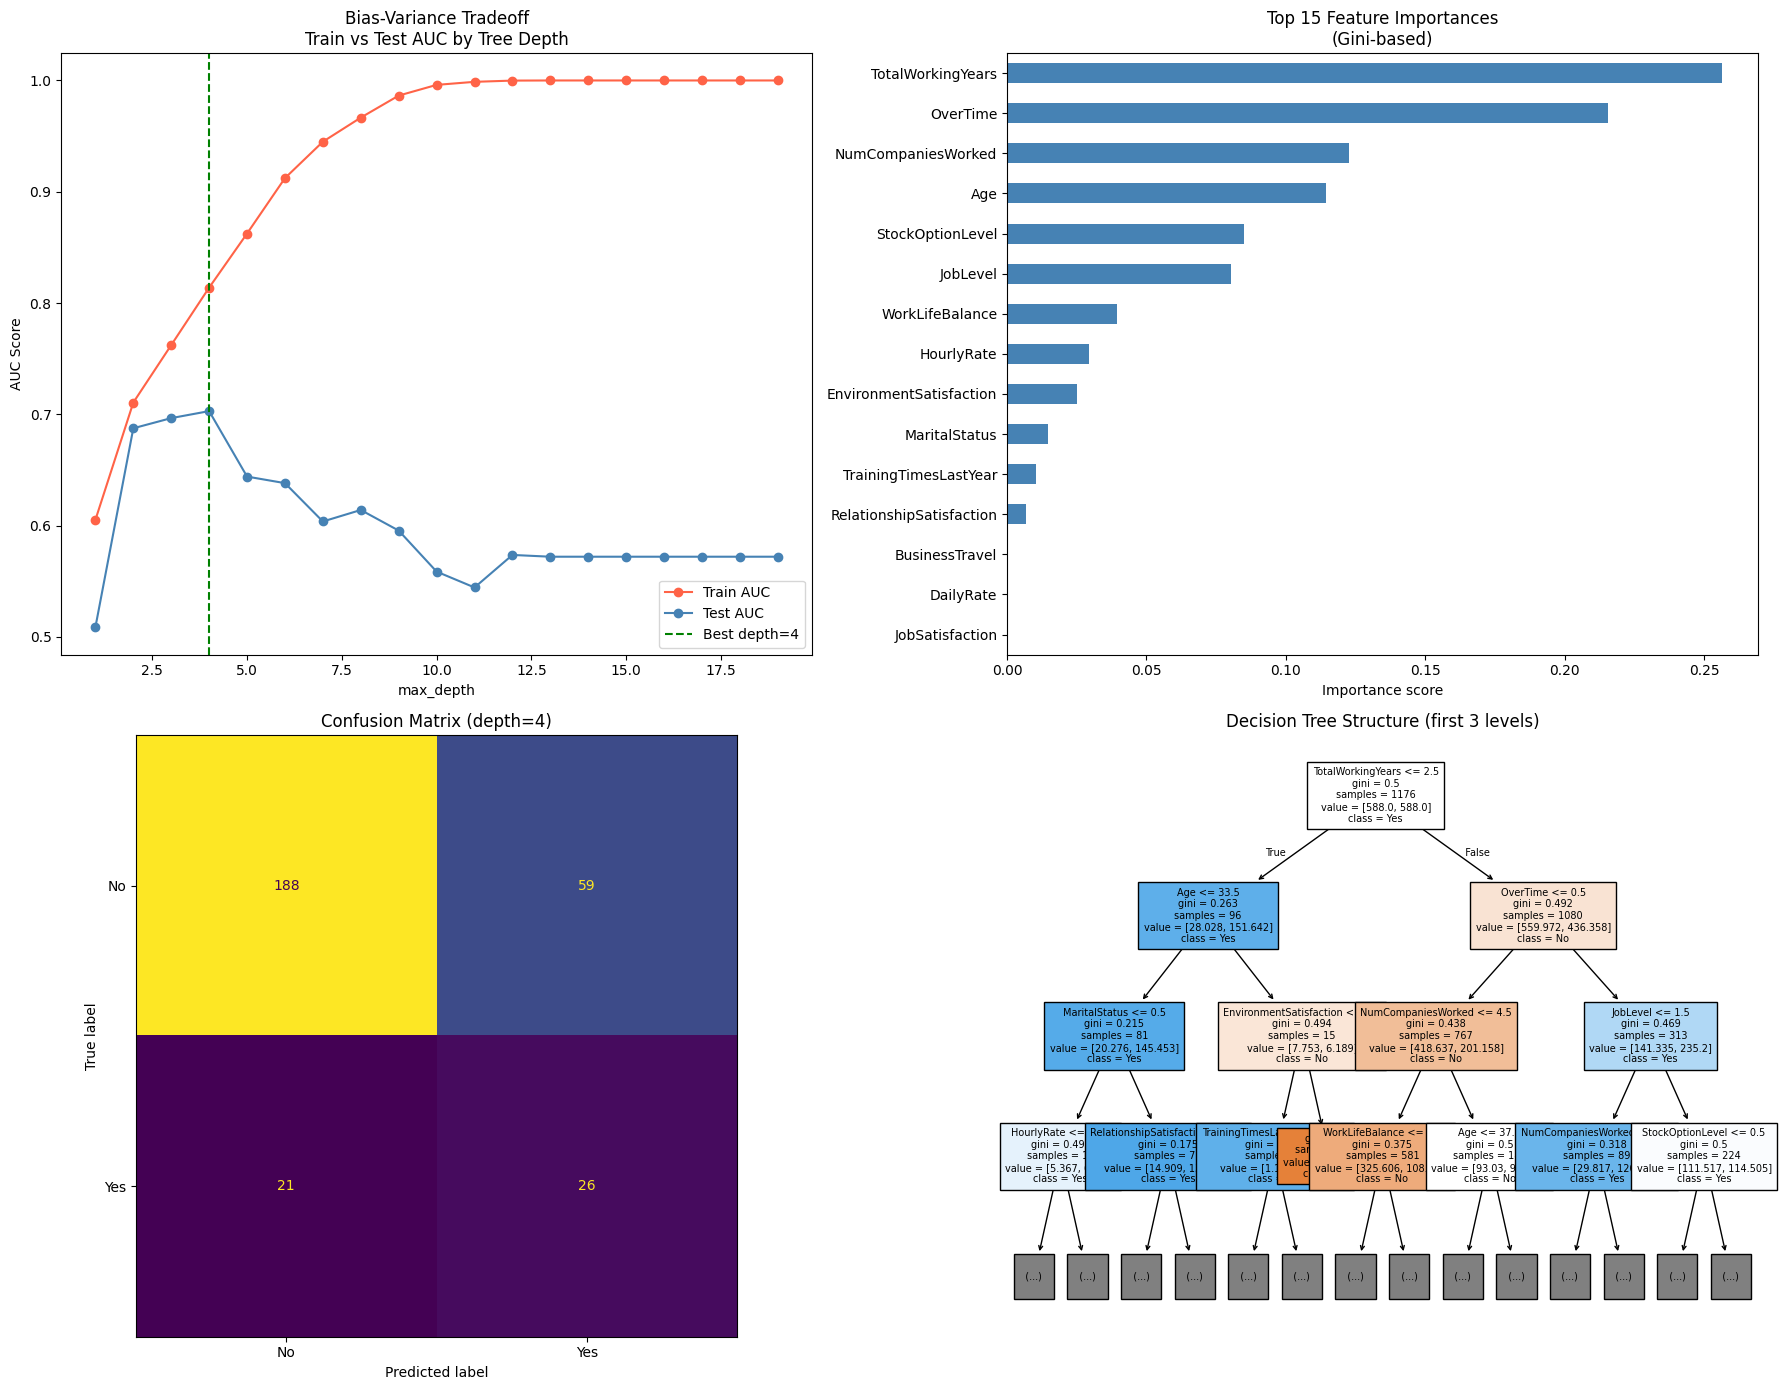

In [ ]:
# 7. Plots 
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Bias-variance tradeoff across depths
axes[0,0].plot(depths, train_aucs, "o-", color="tomato",    label="Train AUC")
axes[0,0].plot(depths, test_aucs,  "o-", color="steelblue", label="Test AUC")
axes[0,0].axvline(best_depth, color="green", linestyle="--",
                  label=f"Best depth={best_depth}")
axes[0,0].set_xlabel("max_depth")
axes[0,0].set_ylabel("AUC Score")
axes[0,0].set_title("Bias-Variance Tradeoff\nTrain vs Test AUC by Tree Depth")
axes[0,0].legend()

# Plot 2: Feature importances
importances.sort_values().plot(kind="barh", ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Top 15 Feature Importances\n(Gini-based)")
axes[0,1].set_xlabel("Importance score")

# Plot 3: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title(f"Confusion Matrix (depth={best_depth})")

# Plot 4: Actual tree visualization (shallow for readability)
plot_tree(dt_best, feature_names=list(X_train_enc.columns),
          class_names=["No", "Yes"], filled=True,
          max_depth=3, ax=axes[1,1], fontsize=7,
          impurity=True, proportion=False)
axes[1,1].set_title("Decision Tree Structure (first 3 levels)")

plt.tight_layout()
plt.show()